In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [3]:
from sklearn.metrics import r2_score , root_mean_squared_error
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
df=pd.read_csv("youtube_views_dataset_with_nulls.csv")
df.head()

,video_length,like_rate,comment_count,upload_hour,hashtag_count,views
0,71,9.51,143.0,21,12.0,14222
1,112,6.00,85.0,16,13.0,13049
2,34,4.16,184.0,8,2.0,9620
3,91,8.08,284.0,0,10.0,14917
4,80,18.97,219.0,20,6.0,21483


In [6]:
df_bkup=df

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   video_length   200 non-null    int64  
 1   like_rate      190 non-null    float64
 2   comment_count  190 non-null    float64
 3   upload_hour    200 non-null    int64  
 4   hashtag_count  190 non-null    float64
 5   views          200 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 9.5 KB


In [8]:
df['like_rate'].isnull().sum()

np.int64(10)

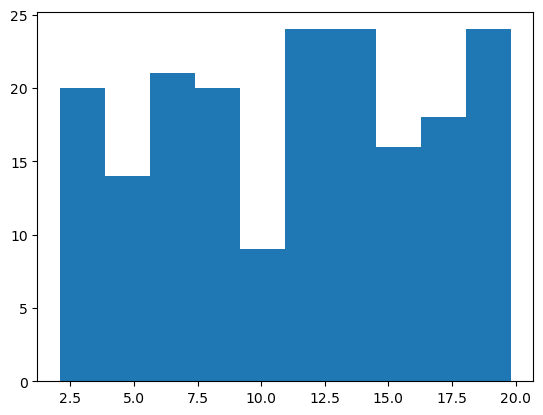

In [9]:
plt.hist(df["like_rate"])
plt.show()

the data is not skewed here so we will use mean

In [10]:
like_mean=df["like_rate"].mean()
df["like_rate"]=df["like_rate"].fillna(like_mean)

In [11]:
df['like_rate'].isnull().sum()

np.int64(0)

like_rate coloumn is cleaned

In [12]:
df["comment_count"].isnull().sum()

np.int64(10)

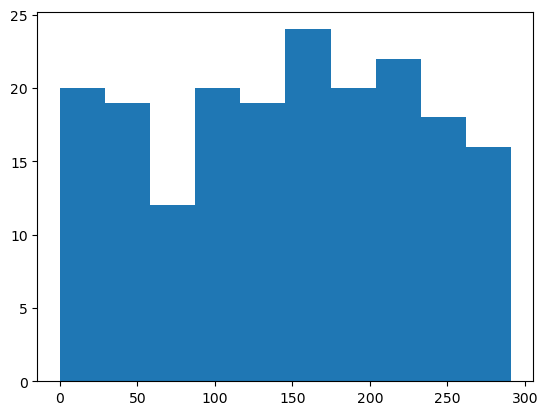

In [13]:
plt.hist(df['comment_count'])
plt.show()

the data here also is not skewed so we will use mean

In [14]:
comment_mean=df["comment_count"].mean()
df["comment_count"]=df["comment_count"].fillna(comment_mean)

In [15]:
df["comment_count"].isnull().sum()

np.int64(0)

the comment data is also cleaned

In [16]:
df["hashtag_count"].isnull().sum()

np.int64(10)

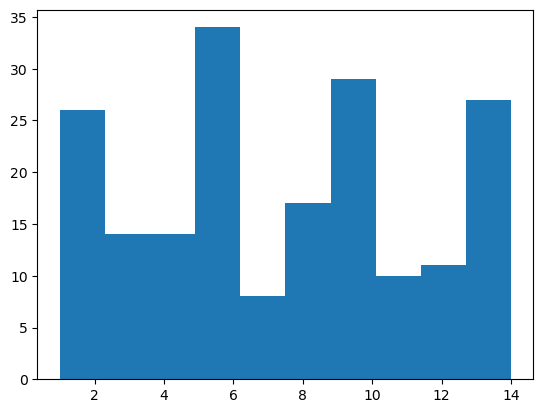

In [17]:
plt.hist(df["hashtag_count"])
plt.show()

In [18]:
hash_mean=df["hashtag_count"].mean()
df["hashtag_count"]=df["hashtag_count"].fillna(hash_mean)

In [19]:
df.isnull().sum()

video_length     0
like_rate        0
comment_count    0
upload_hour      0
hashtag_count    0
views            0
dtype: int64

# the data is cleaned completely

In [20]:
df.head()

,video_length,like_rate,comment_count,upload_hour,hashtag_count,views
0,71,9.51,143.0,21,12.0,14222
1,112,6.00,85.0,16,13.0,13049
2,34,4.16,184.0,8,2.0,9620
3,91,8.08,284.0,0,10.0,14917
4,80,18.97,219.0,20,6.0,21483


In [21]:
df.shape

(200, 6)

### here views is the target varible
### while others are features

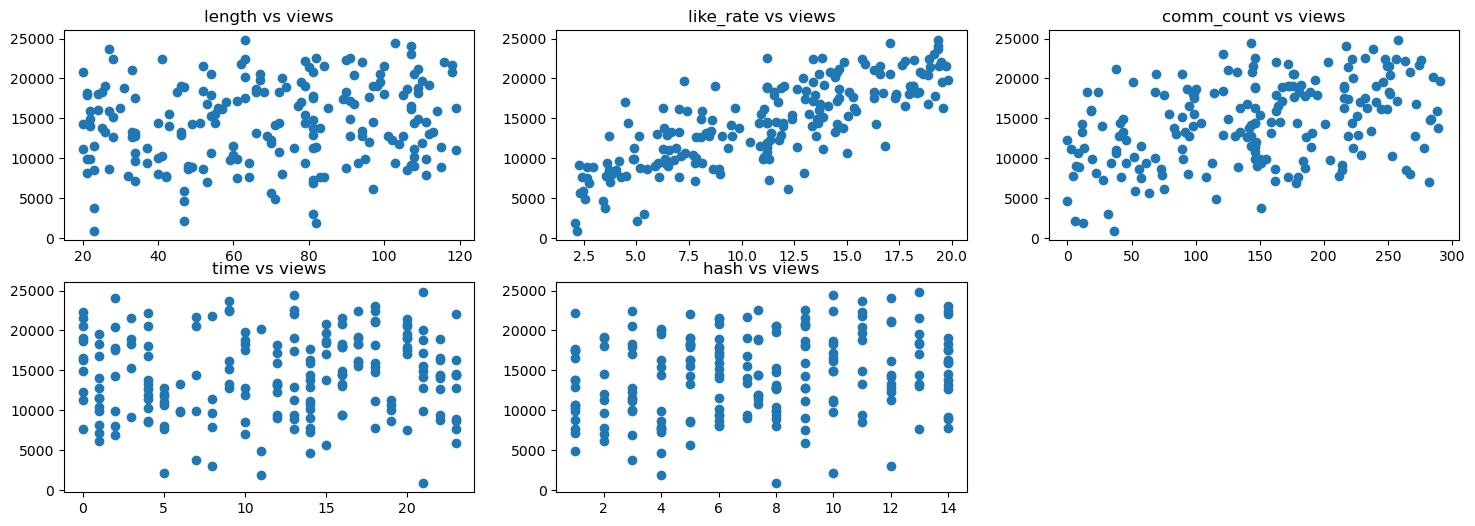

In [22]:
plt.figure(figsize=(18,6))
plt.subplot(2,3,1)
plt.scatter(x=df['video_length'],y=df["views"])
plt.title("length vs views")

plt.subplot(2,3,2)
plt.scatter(x=df["like_rate"],y=df["views"])
plt.title("like_rate vs views")

plt.subplot(2,3,3)
plt.scatter(x=df["comment_count"],y=df["views"])
plt.title("comm_count vs views")

plt.subplot(2,3,4)
plt.scatter(x=df["upload_hour"],y=df["views"])
plt.title("time vs views")

plt.subplot(2,3,5)
plt.scatter(x=df["hashtag_count"],y=df["views"])
plt.title("hash vs views")
plt.show()

In [23]:
X=df[["comment_count","like_rate",'video_length',"upload_hour","hashtag_count"]]
Y=df["views"]

In [29]:
import seaborn as sns

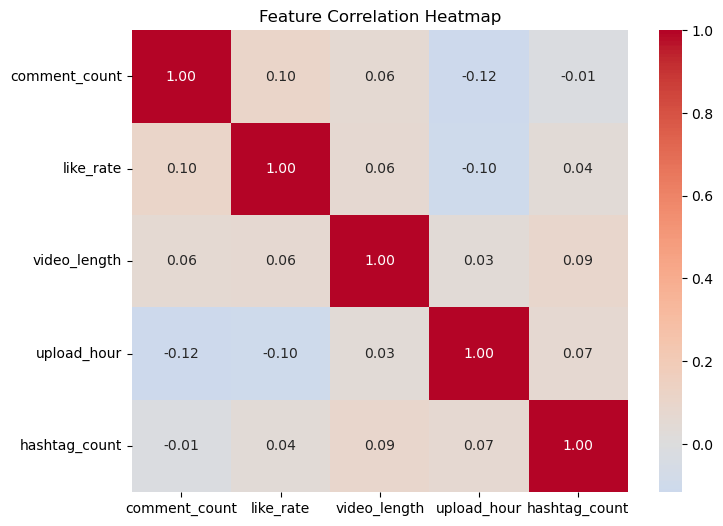

In [34]:
corr=X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [41]:
model=LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [42]:
print(f"the coefficiants are{model.coef_}")
print(f"the intercept is {model.intercept_}")

the coefficiants are[ 21.582563   760.74747797  10.08742494 129.65295066 257.68228658]
the intercept is -1322.4483610403404


In [44]:
r2 = model.score(X_test, Y_test)
print("R2 Score:", r2)

R2 Score: 0.7299278545191668


In [46]:
print("Training R2:", model.score(X_train, Y_train))
print("Testing R2:", model.score(X_test, Y_test))

Training R2: 0.8316549033190683
Testing R2: 0.7299278545191668


In [53]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print("RMSE:", rmse)
print("avg views",Y_test.mean())

RMSE: 2848.056733206638
avg views 13195.925


In [47]:
Y_pred = model.predict(X_test)

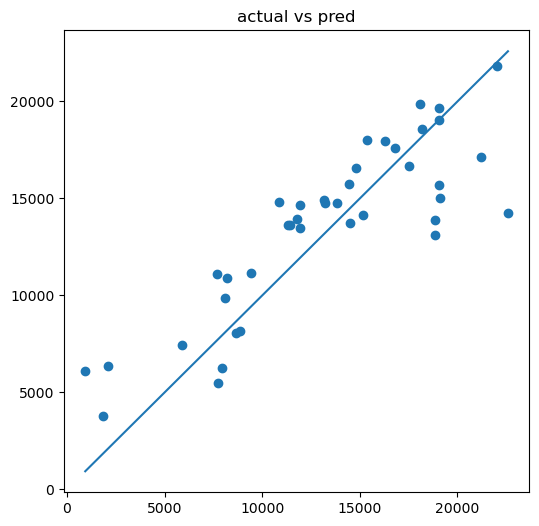

In [49]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test,Y_pred)
plt.title("actual vs pred")
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()])
plt.show()

In [27]:


def predictor():
    comm=int(input("enter no of comments"))
    while True:
        like=int(input("enter like rate")) 
        if 0 <= like <=100: 
            break
        else:
            print("Invalid rate! Please enter between 0 and 100.")
    
    length=int(input("enter video length")) 
    while True:
        time = int(input("Enter upload hour (0 to 23): "))
        if 0 <= time <= 23:
            break
        else:
            print("Invalid hour! Please enter between 0 and 23.")
    hashtag=int(input("enter no of hashtags"))
    features=[[comm,like,length,time,hashtag]]
    predicted_views=model.predict(features)
    print(f"the predicted no of views is {int(predicted_views[0])}")
predictor()

enter no of comments 10
enter like rate 23
enter video length 54
Enter upload hour (0 to 23):  8
enter no of hashtags 6


the predicted no of views is 19612


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The model achieved an R² of 0.73 on test data and RMSE of 2848, indicating reasonably accurate prediction performance.